# Analyse Exploratoire des Données (EDA) - Prédiction de Mortalité

## Objectif
Cette analyse exploratoire vise à comprendre les caractéristiques du dataset clinique pour la prédiction de mortalité. Nous allons examiner :
- La distribution des variables
- Les corrélations entre features
- Les patterns de mortalité
- La qualité des données
- Les insights cliniques

## Dataset
Le dataset contient des données cliniques de patients en soins intensifs avec les variables suivantes :
- **Démographiques** : âge, genre
- **Cliniques** : type d'admission, diagnostic, durée de séjour
- **Traitements** : ventilation mécanique, vasopresseurs
- **Biomarqueurs** : créatinine, bilirubine, plaquettes, lactate
- **Outcome** : mortalité (0=survie, 1=décès)

In [1]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Librairies importées avec succès")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

✅ Librairies importées avec succès
Pandas version: 2.2.3
NumPy version: 2.2.5
Matplotlib version: 3.10.3
Seaborn version: 0.13.2


In [2]:
# Chargement des données
import sys
import os
sys.path.append('../src')

try:
    # Tentative de chargement des données préprocessées
    df = pd.read_csv('../data/processed/processed_data.csv')
    print("✅ Données préprocessées chargées")
except:
    try:
        # Chargement des données brutes
        df = pd.read_csv('../data/raw/clinical_data.csv')
        print("✅ Données brutes chargées")
    except:
        print("❌ Impossible de charger les données. Génération d'un dataset de démonstration...")
        
        # Génération d'un dataset synthétique pour la démonstration
        np.random.seed(42)
        n_patients = 5000
        
        df = pd.DataFrame({
            'patient_id': range(1, n_patients + 1),
            'age': np.random.normal(65, 15, n_patients).clip(18, 95),
            'gender': np.random.choice(['M', 'F'], n_patients),
            'admission_type': np.random.choice(['EMERGENCY', 'ELECTIVE', 'URGENT'], n_patients, p=[0.6, 0.25, 0.15]),
            'diagnosis': np.random.choice(['SEPSIS', 'CARDIOVASCULAR', 'RESPIRATORY', 'NEUROLOGICAL', 'OTHER'], 
                                        n_patients, p=[0.3, 0.25, 0.2, 0.15, 0.1]),
            'icu_stay_days': np.random.exponential(5, n_patients).clip(1, 30),
            'mechanical_ventilation': np.random.choice([0, 1], n_patients, p=[0.6, 0.4]),
            'vasopressor_use': np.random.choice([0, 1], n_patients, p=[0.7, 0.3]),
            'creatinine': np.random.lognormal(0.5, 0.8, n_patients).clip(0.5, 15),
            'bilirubin': np.random.lognormal(0.8, 1.2, n_patients).clip(0.1, 25),
            'platelets': np.random.normal(250000, 100000, n_patients).clip(10000, 500000),
            'lactate': np.random.lognormal(1.2, 0.8, n_patients).clip(0.5, 15)
        })
        
        # Génération de la variable cible avec des corrélations réalistes
        mortality_prob = (
            0.1 +  # base rate
            0.3 * (df['age'] > 70) +
            0.2 * (df['creatinine'] > 2) +
            0.25 * (df['lactate'] > 4) +
            0.2 * df['mechanical_ventilation'] +
            0.15 * df['vasopressor_use'] +
            0.1 * (df['icu_stay_days'] > 10)
        ).clip(0, 1)
        
        df['mortality'] = np.random.binomial(1, mortality_prob)
        print("✅ Dataset synthétique généré pour la démonstration")

print(f"\n📊 Dataset chargé avec {df.shape[0]:,} patients et {df.shape[1]} variables")
print("\n🔍 Aperçu des données:")
df.head()

❌ Impossible de charger les données. Génération d'un dataset de démonstration...
✅ Dataset synthétique généré pour la démonstration

📊 Dataset chargé avec 5,000 patients et 13 variables

🔍 Aperçu des données:


,patient_id,age,gender,admission_type,diagnosis,icu_stay_days,mechanical_ventilation,vasopressor_use,creatinine,bilirubin,platelets,lactate,mortality
0,1,72.450712,F,EMERGENCY,OTHER,1.000000,0,0,3.866433,0.949427,214919.478854,1.200245,1
1,2,62.926035,M,EMERGENCY,NEUROLOGICAL,2.533469,1,1,1.973790,1.720615,287623.393121,2.746537,1
2,3,74.715328,F,URGENT,CARDIOVASCULAR,14.763845,1,0,3.024719,2.249094,220839.251623,1.382559,1
3,4,87.845448,F,EMERGENCY,RESPIRATORY,1.436078,0,0,2.354345,2.445137,221185.311036,1.593888,1
4,5,61.487699,F,EMERGENCY,SEPSIS,14.196742,1,0,1.280093,3.092997,287490.154280,3.309917,0


## 1. Informations Générales sur le Dataset

In [3]:
# Informations sur la structure du dataset
print("📋 INFORMATIONS GÉNÉRALES")
print("=" * 50)
print(f"Nombre de patients: {df.shape[0]:,}")
print(f"Nombre de variables: {df.shape[1]}")
print(f"Taille en mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n📊 TYPES DE VARIABLES")
print("=" * 50)
print(df.dtypes)

print("\n🔍 STATISTIQUES DESCRIPTIVES")
print("=" * 50)
df.describe()

📋 INFORMATIONS GÉNÉRALES
Nombre de patients: 5,000
Nombre de variables: 13
Taille en mémoire: 1.29 MB

📊 TYPES DE VARIABLES
patient_id                  int64
age                       float64
gender                     object
admission_type             object
diagnosis                  object
icu_stay_days             float64
mechanical_ventilation      int64
vasopressor_use             int64
creatinine                float64
bilirubin                 float64
platelets                 float64
lactate                   float64
mortality                   int64
dtype: object

🔍 STATISTIQUES DESCRIPTIVES


,patient_id,age,icu_stay_days,mechanical_ventilation,vasopressor_use,creatinine,bilirubin,platelets,lactate,mortality
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,64.958987,5.294333,0.392400,0.292400,2.245051,4.171965,251130.118195,4.406494,0.522200
std,1443.520003,14.642920,5.072691,0.488334,0.454911,2.021460,5.293677,97616.836576,3.412315,0.499557
min,1.000000,18.000000,1.000000,0.000000,0.000000,0.500000,0.100000,10000.000000,0.500000,0.000000
25%,1250.750000,55.131424,1.519232,0.000000,0.000000,0.942447,0.933875,182890.364797,1.974196,0.000000
50%,2500.500000,65.201984,3.582666,0.000000,0.000000,1.621673,2.176182,252188.736539,3.359670,1.000000
75%,3750.250000,74.990159,7.145505,1.000000,1.000000,2.853649,4.995863,318016.533200,5.731276,1.000000
max,5000.000000,95.000000,30.000000,1.000000,1.000000,15.000000,25.000000,500000.000000,15.000000,1.000000


In [4]:
# Analyse de la qualité des données
print("🔧 QUALITÉ DES DONNÉES")
print("=" * 50)

# Valeurs manquantes
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

quality_df = pd.DataFrame({
    'Variable': df.columns,
    'Type': df.dtypes,
    'Valeurs_Manquantes': missing_data.values,
    'Pourcentage_Manquant': missing_percent.values,
    'Valeurs_Uniques': [df[col].nunique() for col in df.columns]
})

print(quality_df.to_string(index=False))

# Visualisation des valeurs manquantes
if missing_data.sum() > 0:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    missing_data[missing_data > 0].plot(kind='bar')
    plt.title('Nombre de Valeurs Manquantes par Variable')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    missing_percent[missing_percent > 0].plot(kind='bar')
    plt.title('Pourcentage de Valeurs Manquantes par Variable')
    plt.xticks(rotation=45)
    plt.ylabel('Pourcentage (%)')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Aucune valeur manquante détectée!")

# Détection des doublons
duplicates = df.duplicated().sum()
print(f"\n🔄 Doublons détectés: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

🔧 QUALITÉ DES DONNÉES
              Variable    Type  Valeurs_Manquantes  Pourcentage_Manquant  Valeurs_Uniques
            patient_id   int64                   0                   0.0             5000
                   age float64                   0                   0.0             4887
                gender  object                   0                   0.0                2
        admission_type  object                   0                   0.0                3
             diagnosis  object                   0                   0.0                5
         icu_stay_days float64                   0                   0.0             4133
mechanical_ventilation   int64                   0                   0.0                2
       vasopressor_use   int64                   0                   0.0                2
            creatinine float64                   0                   0.0             4629
             bilirubin float64                   0                   0.0      

## 2. Analyse de la Variable Cible (Mortalité)

🎯 ANALYSE DE LA MORTALITÉ
Distribution de la mortalité:
Survivants (0): 2,389 patients (47.8%)
Décédés (1): 2,611 patients (52.2%)


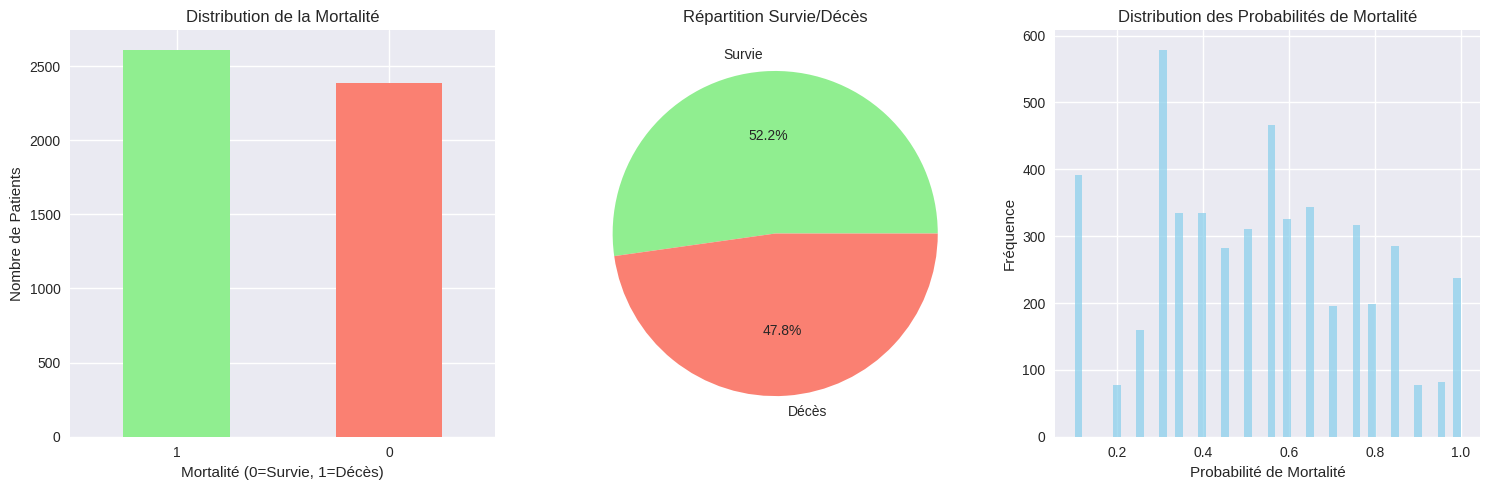


✅ Classes relativement équilibrées


In [5]:
# Analyse de la variable cible
print("🎯 ANALYSE DE LA MORTALITÉ")
print("=" * 50)

# Distribution de la mortalité
mortality_counts = df['mortality'].value_counts()
mortality_percent = df['mortality'].value_counts(normalize=True) * 100

print("Distribution de la mortalité:")
print(f"Survivants (0): {mortality_counts[0]:,} patients ({mortality_percent[0]:.1f}%)")
print(f"Décédés (1): {mortality_counts[1]:,} patients ({mortality_percent[1]:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Graphique en barres
mortality_counts.plot(kind='bar', ax=axes[0], color=['lightgreen', 'salmon'])
axes[0].set_title('Distribution de la Mortalité')
axes[0].set_xlabel('Mortalité (0=Survie, 1=Décès)')
axes[0].set_ylabel('Nombre de Patients')
axes[0].tick_params(axis='x', rotation=0)

# Graphique en camembert
axes[1].pie(mortality_counts.values, labels=['Survie', 'Décès'], autopct='%1.1f%%', 
           colors=['lightgreen', 'salmon'])
axes[1].set_title('Répartition Survie/Décès')

# Graphique interactif avec plotly
fig_plotly = px.pie(values=mortality_counts.values, names=['Survie', 'Décès'], 
                   title='Distribution de la Mortalité',
                   color_discrete_sequence=['lightgreen', 'salmon'])

# Histogramme des probabilités (si disponible)
if 'mortality_prob' in locals():
    axes[2].hist(mortality_prob, bins=50, alpha=0.7, color='skyblue')
    axes[2].set_title('Distribution des Probabilités de Mortalité')
    axes[2].set_xlabel('Probabilité de Mortalité')
    axes[2].set_ylabel('Fréquence')
else:
    axes[2].text(0.5, 0.5, 'Probabilités\nnon disponibles', 
                ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('Probabilités de Mortalité')

plt.tight_layout()
plt.show()

# Affichage du graphique Plotly
fig_plotly.show()

# Statistiques sur les déséquilibres de classe
if mortality_percent.min() < 30:
    print(f"\n⚠️  DÉSÉQUILIBRE DE CLASSE DÉTECTÉ!")
    print(f"La classe minoritaire représente {mortality_percent.min():.1f}% des données")
    print("Considérer des techniques de rééquilibrage (SMOTE, class_weight, etc.)")
else:
    print(f"\n✅ Classes relativement équilibrées")

## 3. Analyse des Variables Démographiques

👥 ANALYSE DÉMOGRAPHIQUE
Âge moyen: 65.0 ans
Âge médian: 65.2 ans
Écart-type: 14.6 ans
Étendue: 18 - 95 ans

Répartition par genre:
M: 2,559 patients (51.2%)
F: 2,441 patients (48.8%)


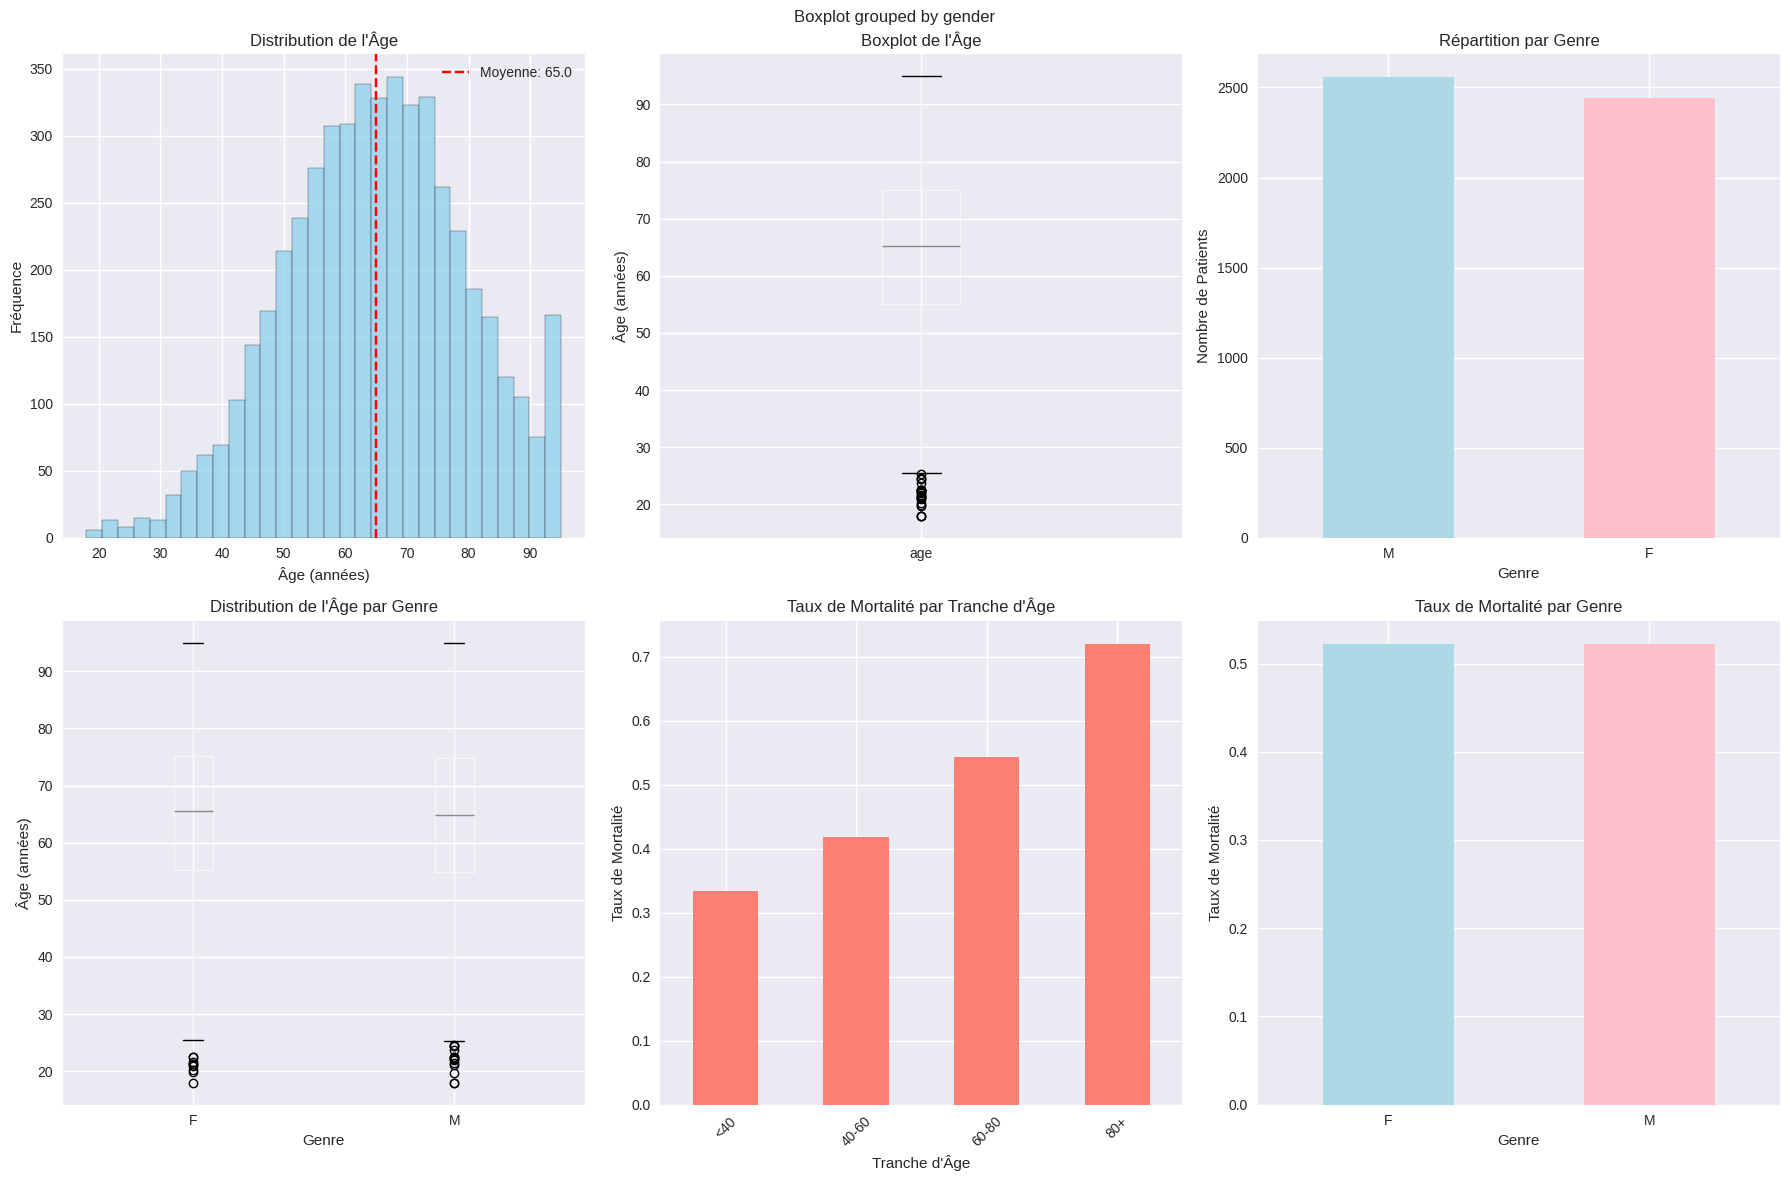


📊 ANALYSE STATISTIQUE
Âge moyen des survivants: 61.2 ans
Âge moyen des décédés: 68.4 ans
Différence d'âge: 7.2 ans
Test t pour l'âge: p-value = 0.000000
✅ Différence d'âge statistiquement significative entre survivants et décédés


In [6]:
# Analyse des variables démographiques
print("👥 ANALYSE DÉMOGRAPHIQUE")
print("=" * 50)

# Analyse de l'âge
print(f"Âge moyen: {df['age'].mean():.1f} ans")
print(f"Âge médian: {df['age'].median():.1f} ans")
print(f"Écart-type: {df['age'].std():.1f} ans")
print(f"Étendue: {df['age'].min():.0f} - {df['age'].max():.0f} ans")

# Analyse du genre
gender_counts = df['gender'].value_counts()
gender_percent = df['gender'].value_counts(normalize=True) * 100
print(f"\nRépartition par genre:")
for gender, count in gender_counts.items():
    print(f"{gender}: {count:,} patients ({gender_percent[gender]:.1f}%)")

# Visualisations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Distribution de l'âge
axes[0, 0].hist(df['age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution de l\'Âge')
axes[0, 0].set_xlabel('Âge (années)')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["age"].mean():.1f}')
axes[0, 0].legend()

# Boxplot de l'âge
df.boxplot(column='age', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot de l\'Âge')
axes[0, 1].set_ylabel('Âge (années)')

# Distribution du genre
gender_counts.plot(kind='bar', ax=axes[0, 2], color=['lightblue', 'pink'])
axes[0, 2].set_title('Répartition par Genre')
axes[0, 2].set_xlabel('Genre')
axes[0, 2].set_ylabel('Nombre de Patients')
axes[0, 2].tick_params(axis='x', rotation=0)

# Âge par genre
df.boxplot(column='age', by='gender', ax=axes[1, 0])
axes[1, 0].set_title('Distribution de l\'Âge par Genre')
axes[1, 0].set_xlabel('Genre')
axes[1, 0].set_ylabel('Âge (années)')

# Mortalité par tranche d'âge
age_bins = pd.cut(df['age'], bins=[0, 40, 60, 80, 100], labels=['<40', '40-60', '60-80', '80+'])
mortality_by_age = df.groupby(age_bins)['mortality'].agg(['mean', 'count'])
mortality_by_age['mean'].plot(kind='bar', ax=axes[1, 1], color='salmon')
axes[1, 1].set_title('Taux de Mortalité par Tranche d\'Âge')
axes[1, 1].set_xlabel('Tranche d\'Âge')
axes[1, 1].set_ylabel('Taux de Mortalité')
axes[1, 1].tick_params(axis='x', rotation=45)

# Mortalité par genre
mortality_by_gender = df.groupby('gender')['mortality'].mean()
mortality_by_gender.plot(kind='bar', ax=axes[1, 2], color=['lightblue', 'pink'])
axes[1, 2].set_title('Taux de Mortalité par Genre')
axes[1, 2].set_xlabel('Genre')
axes[1, 2].set_ylabel('Taux de Mortalité')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Analyse statistique des différences
print(f"\n📊 ANALYSE STATISTIQUE")
print("=" * 30)
print(f"Âge moyen des survivants: {df[df['mortality']==0]['age'].mean():.1f} ans")
print(f"Âge moyen des décédés: {df[df['mortality']==1]['age'].mean():.1f} ans")
print(f"Différence d'âge: {df[df['mortality']==1]['age'].mean() - df[df['mortality']==0]['age'].mean():.1f} ans")

# Test statistique (t-test)
from scipy.stats import ttest_ind
stat, pvalue = ttest_ind(df[df['mortality']==0]['age'], df[df['mortality']==1]['age'])
print(f"Test t pour l'âge: p-value = {pvalue:.6f}")
if pvalue < 0.05:
    print("✅ Différence d'âge statistiquement significative entre survivants et décédés")
else:
    print("❌ Pas de différence d'âge statistiquement significative")

## 4. Analyse des Variables Cliniques

🏥 ANALYSE DES VARIABLES CLINIQUES
Type d'admission:
EMERGENCY: 3,019 patients (60.4%)
ELECTIVE: 1,212 patients (24.2%)
URGENT: 769 patients (15.4%)

Diagnostic principal:
SEPSIS: 1,428 patients (28.6%)
CARDIOVASCULAR: 1,277 patients (25.5%)
RESPIRATORY: 1,005 patients (20.1%)
NEUROLOGICAL: 795 patients (15.9%)
OTHER: 495 patients (9.9%)

Durée de séjour en USI:
Moyenne: 5.3 jours
Médiane: 3.6 jours
Écart-type: 5.1 jours
Étendue: 1 - 30 jours


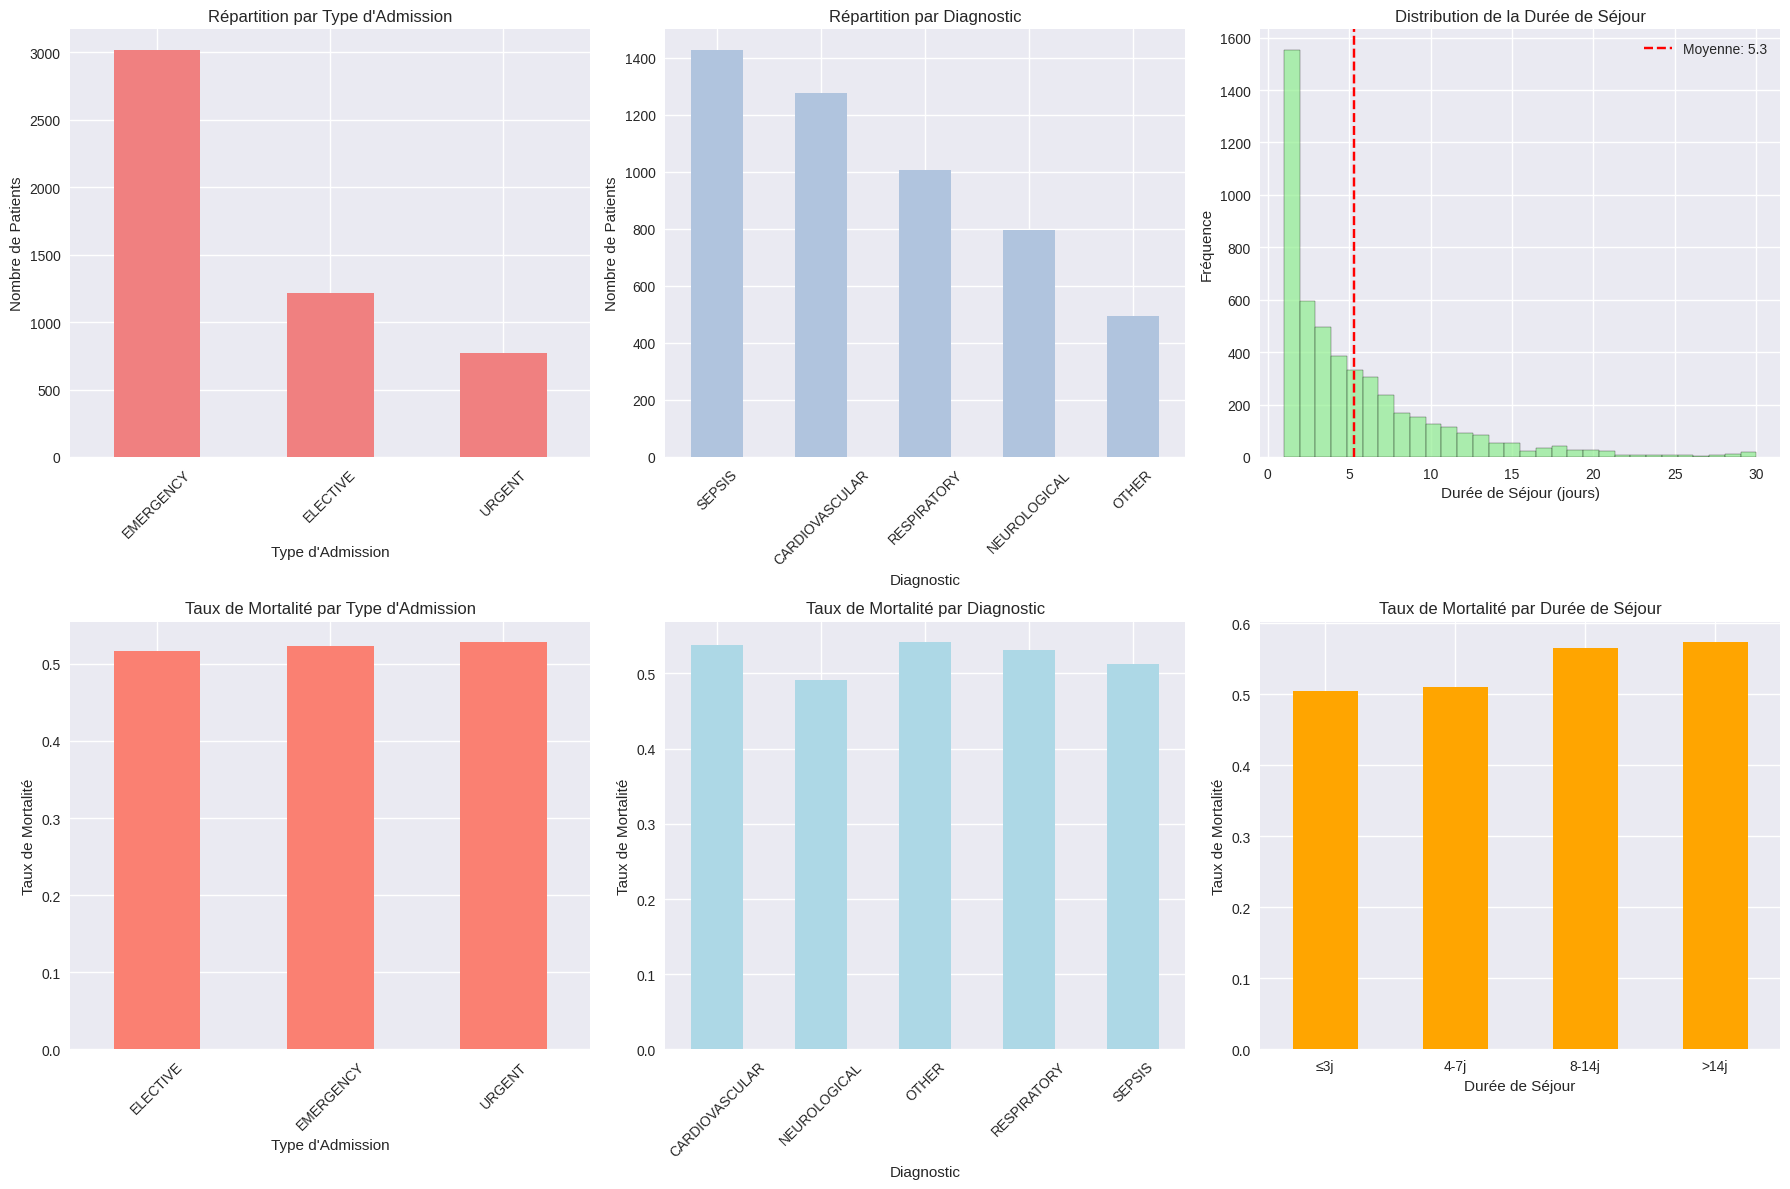


🔍 ANALYSE DÉTAILLÉE PAR DIAGNOSTIC
                Nb_Patients  Nb_Décès  Taux_Mortalité  Âge_Moyen  Durée_Séjour_Moyenne
diagnosis                                                                             
CARDIOVASCULAR         1277       686            0.54      64.81                  5.29
NEUROLOGICAL            795       391            0.49      64.88                  5.33
OTHER                   495       268            0.54      64.78                  5.16
RESPIRATORY            1005       534            0.53      65.38                  5.46
SEPSIS                 1428       732            0.51      64.90                  5.21


In [7]:
# Analyse des variables cliniques
print("🏥 ANALYSE DES VARIABLES CLINIQUES")
print("=" * 50)

# Type d'admission
print("Type d'admission:")
admission_counts = df['admission_type'].value_counts()
for admission_type, count in admission_counts.items():
    percent = count / len(df) * 100
    print(f"{admission_type}: {count:,} patients ({percent:.1f}%)")

# Diagnostic
print("\nDiagnostic principal:")
diagnosis_counts = df['diagnosis'].value_counts()
for diagnosis, count in diagnosis_counts.items():
    percent = count / len(df) * 100
    print(f"{diagnosis}: {count:,} patients ({percent:.1f}%)")

# Durée de séjour en USI
print(f"\nDurée de séjour en USI:")
print(f"Moyenne: {df['icu_stay_days'].mean():.1f} jours")
print(f"Médiane: {df['icu_stay_days'].median():.1f} jours")
print(f"Écart-type: {df['icu_stay_days'].std():.1f} jours")
print(f"Étendue: {df['icu_stay_days'].min():.0f} - {df['icu_stay_days'].max():.0f} jours")

# Visualisations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Type d'admission
admission_counts.plot(kind='bar', ax=axes[0, 0], color='lightcoral')
axes[0, 0].set_title('Répartition par Type d\'Admission')
axes[0, 0].set_xlabel('Type d\'Admission')
axes[0, 0].set_ylabel('Nombre de Patients')
axes[0, 0].tick_params(axis='x', rotation=45)

# Diagnostic
diagnosis_counts.plot(kind='bar', ax=axes[0, 1], color='lightsteelblue')
axes[0, 1].set_title('Répartition par Diagnostic')
axes[0, 1].set_xlabel('Diagnostic')
axes[0, 1].set_ylabel('Nombre de Patients')
axes[0, 1].tick_params(axis='x', rotation=45)

# Durée de séjour
axes[0, 2].hist(df['icu_stay_days'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Distribution de la Durée de Séjour')
axes[0, 2].set_xlabel('Durée de Séjour (jours)')
axes[0, 2].set_ylabel('Fréquence')
axes[0, 2].axvline(df['icu_stay_days'].mean(), color='red', linestyle='--', 
                  label=f'Moyenne: {df["icu_stay_days"].mean():.1f}')
axes[0, 2].legend()

# Mortalité par type d'admission
mortality_by_admission = df.groupby('admission_type')['mortality'].mean()
mortality_by_admission.plot(kind='bar', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Taux de Mortalité par Type d\'Admission')
axes[1, 0].set_xlabel('Type d\'Admission')
axes[1, 0].set_ylabel('Taux de Mortalité')
axes[1, 0].tick_params(axis='x', rotation=45)

# Mortalité par diagnostic
mortality_by_diagnosis = df.groupby('diagnosis')['mortality'].mean()
mortality_by_diagnosis.plot(kind='bar', ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Taux de Mortalité par Diagnostic')
axes[1, 1].set_xlabel('Diagnostic')
axes[1, 1].set_ylabel('Taux de Mortalité')
axes[1, 1].tick_params(axis='x', rotation=45)

# Durée de séjour vs mortalité
stay_bins = pd.cut(df['icu_stay_days'], bins=[0, 3, 7, 14, 30], labels=['≤3j', '4-7j', '8-14j', '>14j'])
mortality_by_stay = df.groupby(stay_bins)['mortality'].mean()
mortality_by_stay.plot(kind='bar', ax=axes[1, 2], color='orange')
axes[1, 2].set_title('Taux de Mortalité par Durée de Séjour')
axes[1, 2].set_xlabel('Durée de Séjour')
axes[1, 2].set_ylabel('Taux de Mortalité')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Analyse détaillée par diagnostic
print(f"\n🔍 ANALYSE DÉTAILLÉE PAR DIAGNOSTIC")
print("=" * 50)
diagnosis_analysis = df.groupby('diagnosis').agg({
    'mortality': ['count', 'sum', 'mean'],
    'age': 'mean',
    'icu_stay_days': 'mean'
}).round(2)

diagnosis_analysis.columns = ['Nb_Patients', 'Nb_Décès', 'Taux_Mortalité', 'Âge_Moyen', 'Durée_Séjour_Moyenne']
print(diagnosis_analysis.to_string())

## 5. Analyse des Biomarqueurs

🧪 ANALYSE DES BIOMARQUEURS
Statistiques descriptives des biomarqueurs:
       creatinine  bilirubin  platelets  lactate
count     5000.00    5000.00    5000.00  5000.00
mean         2.25       4.17  251130.12     4.41
std          2.02       5.29   97616.84     3.41
min          0.50       0.10   10000.00     0.50
25%          0.94       0.93  182890.36     1.97
50%          1.62       2.18  252188.74     3.36
75%          2.85       5.00  318016.53     5.73
max         15.00      25.00  500000.00    15.00


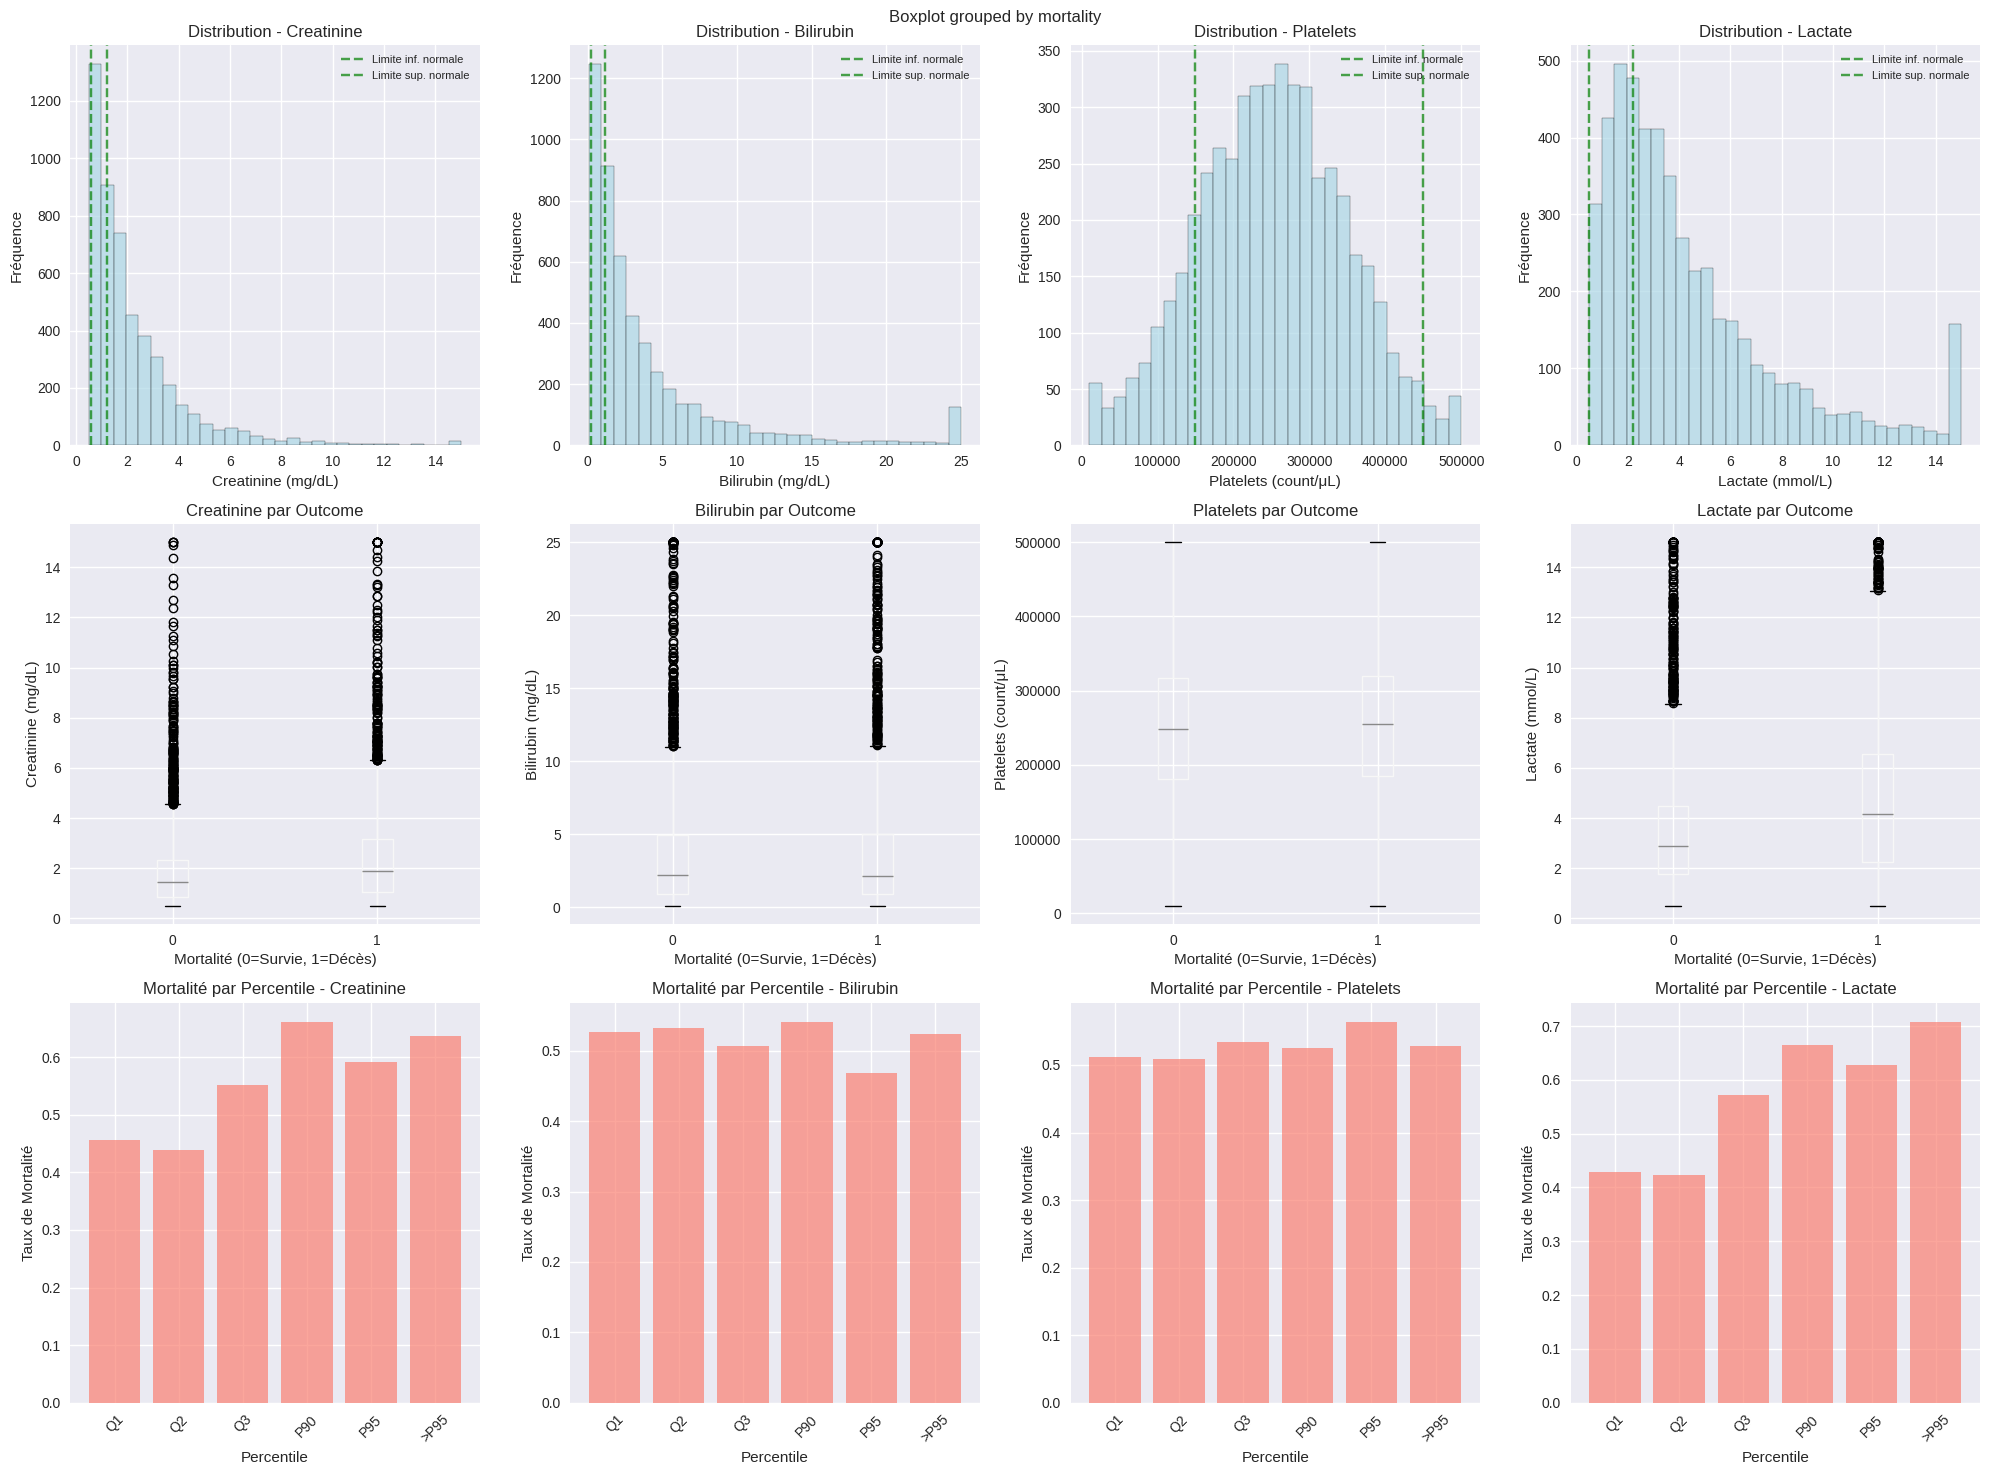


📊 COMPARAISON SURVIVANTS VS DÉCÉDÉS
            creatinine_survivants  creatinine_décédés  creatinine_différence  \
Moyenne                      1.98                2.49                   0.51   
Médiane                      1.44                1.90                   0.46   
Écart-type                   1.81                2.17                   0.36   

            bilirubin_survivants  bilirubin_décédés  bilirubin_différence  \
Moyenne                     4.22               4.12                 -0.10   
Médiane                     2.23               2.13                 -0.10   
Écart-type                  5.35               5.24                 -0.11   

            platelets_survivants  platelets_décédés  platelets_différence  \
Moyenne                249096.71          252990.63               3893.92   
Médiane                248638.18          254810.31               6172.13   
Écart-type              97584.23           97628.25                 44.02   

            lactate_surv

In [8]:
# Analyse des biomarqueurs
biomarkers = ['creatinine', 'bilirubin', 'platelets', 'lactate']

print("🧪 ANALYSE DES BIOMARQUEURS")
print("=" * 50)

# Statistiques descriptives pour chaque biomarqueur
biomarker_stats = df[biomarkers].describe()
print("Statistiques descriptives des biomarqueurs:")
print(biomarker_stats.round(2))

# Valeurs de référence cliniques
reference_ranges = {
    'creatinine': {'normal': (0.6, 1.2), 'unit': 'mg/dL'},
    'bilirubin': {'normal': (0.2, 1.2), 'unit': 'mg/dL'},
    'platelets': {'normal': (150000, 450000), 'unit': 'count/μL'},
    'lactate': {'normal': (0.5, 2.2), 'unit': 'mmol/L'}
}

# Visualisations
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Distributions des biomarqueurs
for i, biomarker in enumerate(biomarkers):
    # Distribution globale
    axes[0, i].hist(df[biomarker], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
    axes[0, i].set_title(f'Distribution - {biomarker.title()}')
    axes[0, i].set_xlabel(f'{biomarker.title()} ({reference_ranges[biomarker]["unit"]})')
    axes[0, i].set_ylabel('Fréquence')
    
    # Ligne de référence normale (si applicable)
    normal_range = reference_ranges[biomarker]['normal']
    axes[0, i].axvline(normal_range[0], color='green', linestyle='--', alpha=0.7, label='Limite inf. normale')
    axes[0, i].axvline(normal_range[1], color='green', linestyle='--', alpha=0.7, label='Limite sup. normale')
    axes[0, i].legend(fontsize=8)
    
    # Boxplot par outcome
    df.boxplot(column=biomarker, by='mortality', ax=axes[1, i])
    axes[1, i].set_title(f'{biomarker.title()} par Outcome')
    axes[1, i].set_xlabel('Mortalité (0=Survie, 1=Décès)')
    axes[1, i].set_ylabel(f'{biomarker.title()} ({reference_ranges[biomarker]["unit"]})')
    
    # Relation avec la mortalité (percentiles)
    percentiles = np.percentile(df[biomarker], [25, 50, 75, 90, 95])
    mortality_by_percentile = []
    labels = ['Q1', 'Q2', 'Q3', 'P90', 'P95']
    
    for j in range(len(percentiles)):
        if j == 0:
            mask = df[biomarker] <= percentiles[j]
        else:
            mask = (df[biomarker] > percentiles[j-1]) & (df[biomarker] <= percentiles[j])
        
        mortality_rate = df[mask]['mortality'].mean() if mask.sum() > 0 else 0
        mortality_by_percentile.append(mortality_rate)
    
    # Ajouter les valeurs au-dessus du P95
    mask = df[biomarker] > percentiles[-1]
    mortality_rate = df[mask]['mortality'].mean() if mask.sum() > 0 else 0
    mortality_by_percentile.append(mortality_rate)
    labels.append('>P95')
    
    axes[2, i].bar(labels, mortality_by_percentile, color='salmon', alpha=0.7)
    axes[2, i].set_title(f'Mortalité par Percentile - {biomarker.title()}')
    axes[2, i].set_xlabel('Percentile')
    axes[2, i].set_ylabel('Taux de Mortalité')
    axes[2, i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Analyse comparative survivants vs décédés
print(f"\n📊 COMPARAISON SURVIVANTS VS DÉCÉDÉS")
print("=" * 50)

comparison_df = pd.DataFrame()
for biomarker in biomarkers:
    survivors = df[df['mortality'] == 0][biomarker]
    deceased = df[df['mortality'] == 1][biomarker]
    
    comparison_df[f'{biomarker}_survivants'] = [survivors.mean(), survivors.median(), survivors.std()]
    comparison_df[f'{biomarker}_décédés'] = [deceased.mean(), deceased.median(), deceased.std()]
    comparison_df[f'{biomarker}_différence'] = [
        deceased.mean() - survivors.mean(),
        deceased.median() - survivors.median(),
        deceased.std() - survivors.std()
    ]

comparison_df.index = ['Moyenne', 'Médiane', 'Écart-type']
print(comparison_df.round(2))

# Tests statistiques pour identifier les biomarqueurs significatifs
print(f"\n🔬 TESTS STATISTIQUES")
print("=" * 30)

significant_biomarkers = []
for biomarker in biomarkers:
    survivors = df[df['mortality'] == 0][biomarker]
    deceased = df[df['mortality'] == 1][biomarker]
    
    # Test de Mann-Whitney U (non-paramétrique)
    from scipy.stats import mannwhitneyu
    stat, pvalue = mannwhitneyu(survivors, deceased, alternative='two-sided')
    
    print(f"{biomarker.title()}:")
    print(f"  Mann-Whitney U p-value: {pvalue:.6f}")
    
    if pvalue < 0.05:
        significant_biomarkers.append(biomarker)
        print(f"  ✅ Différence statistiquement significative")
    else:
        print(f"  ❌ Pas de différence statistiquement significative")
    print()

print(f"🎯 Biomarqueurs significatifs pour la mortalité: {', '.join(significant_biomarkers)}")

## 6. Analyse des Corrélations

In [ ]:
# Analyse des corrélations
print("🔗 ANALYSE DES CORRÉLATIONS")
print("=" * 50)

# Sélection des variables numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'patient_id' in numeric_cols:
    numeric_cols.remove('patient_id')

# Matrice de corrélation
correlation_matrix = df[numeric_cols].corr()

# Visualisation de la matrice de corrélation
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdYlBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8})
plt.title('Matrice de Corrélation des Variables Numériques')
plt.tight_layout()
plt.show()

# Corrélations avec la mortalité (triées)
mortality_corr = correlation_matrix['mortality'].abs().sort_values(ascending=False)
mortality_corr = mortality_corr.drop('mortality')  # Enlever l'auto-corrélation

print("Corrélations absolues avec la mortalité (triées par importance):")
print("-" * 60)
for var, corr in mortality_corr.items():
    direction = "📈" if correlation_matrix['mortality'][var] > 0 else "📉"
    print(f"{var:<20}: {direction} {correlation_matrix['mortality'][var]:>7.3f} (|{corr:.3f}|)")

# Top corrélations (hors mortalité)
print(f"\n🔝 TOP CORRÉLATIONS ENTRE VARIABLES")
print("=" * 50)

# Trouver les corrélations les plus élevées (hors diagonale et mortalité)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        var1 = correlation_matrix.columns[i]
        var2 = correlation_matrix.columns[j]
        if var1 != 'mortality' and var2 != 'mortality':
            corr_val = correlation_matrix.iloc[i, j]
            corr_pairs.append((var1, var2, corr_val, abs(corr_val)))

# Trier par corrélation absolue
corr_pairs_sorted = sorted(corr_pairs, key=lambda x: x[3], reverse=True)

print("Top 10 des corrélations entre variables (hors mortalité):")
for i, (var1, var2, corr, abs_corr) in enumerate(corr_pairs_sorted[:10], 1):
    direction = "📈" if corr > 0 else "📉"
    print(f"{i:2d}. {var1:<15} ↔ {var2:<15}: {direction} {corr:>6.3f}")

# Heatmap spécifique pour les variables les plus corrélées avec la mortalité
top_mortality_vars = mortality_corr.head(8).index.tolist() + ['mortality']
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_mortality_vars].corr(),
            annot=True,
            cmap='RdYlBu_r',
            center=0,
            square=True,
            fmt='.3f')
plt.title('Corrélations - Variables les Plus Liées à la Mortalité')
plt.tight_layout()
plt.show()

# Détection de multicolinéarité potentielle
print(f"\n⚠️  DÉTECTION DE MULTICOLINÉARITÉ")
print("=" * 40)
high_corr_threshold = 0.7
high_correlations = []

for var1, var2, corr, abs_corr in corr_pairs_sorted:
    if abs_corr >= high_corr_threshold:
        high_correlations.append((var1, var2, corr))

if high_correlations:
    print(f"Variables avec corrélation |r| ≥ {high_corr_threshold}:")
    for var1, var2, corr in high_correlations:
        print(f"• {var1} ↔ {var2}: r = {corr:.3f}")
    print(f"\n💡 Considérer la suppression de variables redondantes ou l'utilisation de PCA")
else:
    print(f"✅ Pas de corrélations élevées (|r| ≥ {high_corr_threshold}) détectées")

# Graphiques scatter pour les top corrélations avec mortalité
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
top_4_vars = mortality_corr.head(4).index.tolist()

for i, var in enumerate(top_4_vars):
    row = i // 2
    col = i % 2
    
    # Scatter plot avec jitter pour la mortalité
    mortality_jitter = df['mortality'] + np.random.normal(0, 0.02, len(df))
    
    axes[row, col].scatter(df[var], mortality_jitter, alpha=0.5, s=10)
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Mortalité (avec jitter)')
    axes[row, col].set_title(f'{var} vs Mortalité (r={correlation_matrix["mortality"][var]:.3f})')
    
    # Ligne de régression
    z = np.polyfit(df[var], df['mortality'], 1)
    p = np.poly1d(z)
    axes[row, col].plot(df[var].sort_values(), p(df[var].sort_values()), "r--", alpha=0.8)

plt.tight_layout()
plt.show()